Shortest Path
A->B->E->G
Total Cost: 8


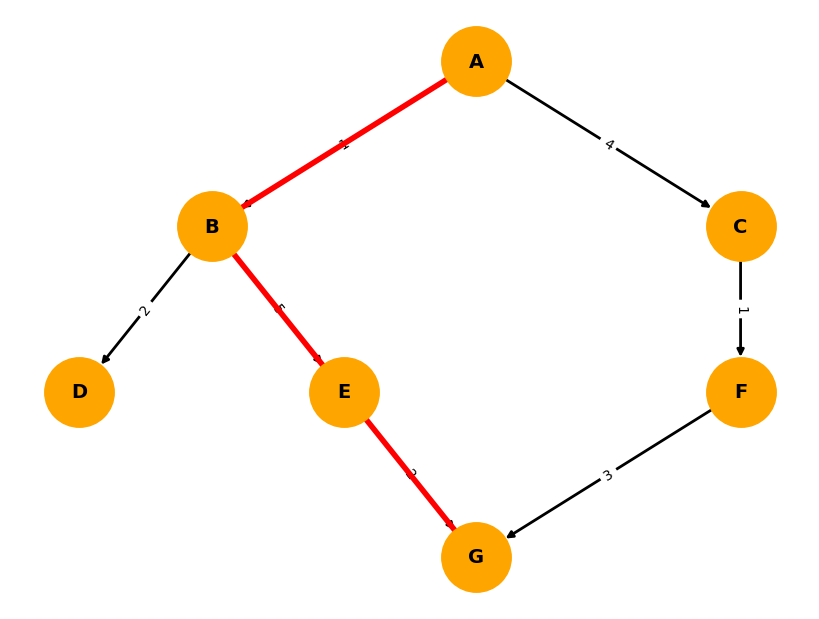

In [15]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt
graph={
    'A':[('B',1),('C',4)],
    'B':[('D',2),('E',5)],
    'C':[('F',1)],
    'D':[],
    'E':[('G',2)],
    'F':[('G',3)],
    'G':[]
}
heuristic={
    'A':7,
    'B':6,
    'C':2,
    'D':5,
    'E':2,
    'F':1,
    'G':0
}
def astar(graph,heuristic,start,goal):
    pq=[(heuristic[start],0,start,[start])]
    visited=set()
    while pq:
        f,g,node,path=heapq.heappop(pq)
        if node==goal:
            return path,g
        if node in visited:
            continue
        visited.add(node)
        for neighbor,cost in graph[node]:
            new_g = g + cost
            new_f = new_g+heuristic[neighbor]
            heapq.heappush(pq,(new_f,new_g,neighbor,path+[neighbor]))
    return None,float('inf')
path,cost=astar(graph,heuristic,'A','G')
print("Shortest Path")
print("->".join(path))
print("Total Cost:",cost)
G= nx.DiGraph()
for node in graph:
    for neighbor, weight in graph[node]:
        G.add_edge(node,neighbor,weight=weight)
pos= {'A':(0,3), 
      'B':(-1,2), 
      'C':(1,2), 
      'D':(-1.5,1), 
      'E':(-0.5,1), 
      'F':(1,1), 
      'G':(0,0)
}
plt.figure(figsize=(8,6))
nx.draw(
    G,pos,
    with_labels=True,
    node_color='orange',
    node_size=2500,
    font_size=14,
    font_weight='bold',
    edge_color='black',
    arrows=True,
    width=2
)
edge_labels=nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)
path_edges=list(zip(path[:-1],path[1:]))
nx.draw_networkx_edges(
    G,pos,edgelist=path_edges,
    edge_color='red',
    width=4,
    arrows=True
)
